# Tutorial Notebook 1: Step-by-Step Classification with Vienna Airbnb Data

## What this notebook teaches
In this tutorial, students will:

1. load a real geospatial dataset,
2. create a simple **classification** target,
3. build **one classifier step by step**,
4. understand what a **preprocessing pipeline** is doing,
5. reuse the same workflow for **multiple classifiers**, and
6. try a few **hyperparameter changes** manually.

## Models included in this tutorial
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree

## Models intentionally left for the later grading notebook
- Support Vector Machine (SVM)
- Random Forest

## Important simplification
We **do not use PCA here**, because the goal is to make preprocessing and model training easier to follow.


In [1]:
# ============================================================
# 0. Imports and plotting settings
# ============================================================
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 1. Resolve file paths

This cell makes the notebook more portable.

It first looks for the data in:
- a `data/` folder,
- the current working folder,
- `/mnt/data` (useful in cloud or notebook environments).

That way, students do not need to edit paths manually every time.


In [2]:
# ============================================================
# 1. Resolve file paths
# ============================================================
DATA_CANDIDATES = [
    Path("data"),
    Path("."),
]

def resolve_path(filename):
    for folder in DATA_CANDIDATES:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in any expected folder.")

LISTINGS_PATH = resolve_path("listings_Vienna.csv")
NEIGHBOURHOODS_PATH = resolve_path("neighbourhoods.geojson")

print("Listings file:", LISTINGS_PATH)
print("Neighbourhood file:", NEIGHBOURHOODS_PATH)


Listings file: data\listings_Vienna.csv
Neighbourhood file: data\neighbourhoods.geojson


## 2. Load the data and make it spatial

The Airbnb file is a normal table.  
To do geospatial work, we convert each listing into a **point geometry** using longitude and latitude.

Then we spatially join each listing to a neighbourhood polygon.


In [3]:
# ============================================================
# 2. Load CSV + GeoJSON and create a GeoDataFrame
# ============================================================
listings = pd.read_csv(LISTINGS_PATH)
neighbourhoods = gpd.read_file(NEIGHBOURHOODS_PATH)

print("Listings shape:", listings.shape)
print("Neighbourhood polygons shape:", neighbourhoods.shape)
print("\nA few listing columns:")
print(listings.columns[:20].tolist())

# Convert the plain table into spatial points
listings_gdf = gpd.GeoDataFrame(
    listings.copy(),
    geometry=gpd.points_from_xy(listings["longitude"], listings["latitude"]),
    crs="EPSG:4326",
)

# Identify a likely neighbourhood name column in the polygons
possible_name_columns = [c for c in neighbourhoods.columns if c != "geometry"]
if "neighbourhood" in neighbourhoods.columns:
    polygon_name_col = "neighbourhood"
elif "neighbourhoods" in neighbourhoods.columns:
    polygon_name_col = "neighbourhoods"
else:
    polygon_name_col = possible_name_columns[0]

# Spatial join: assign each point to the polygon it falls inside
spatial = gpd.sjoin(
    listings_gdf,
    neighbourhoods[[polygon_name_col, "geometry"]],
    how="left",
    predicate="within",
)

# Standardize the joined column name
if f"{polygon_name_col}_right" in spatial.columns:
    spatial = spatial.rename(columns={f"{polygon_name_col}_right": "neighbourhood_joined"})
elif polygon_name_col in spatial.columns and "neighbourhood_joined" not in spatial.columns:
    spatial = spatial.rename(columns={polygon_name_col: "neighbourhood_joined"})

print("\nSpatial join complete.")
print("Joined data shape:", spatial.shape)
print("Missing joined neighbourhood labels:", spatial["neighbourhood_joined"].isna().sum())


Listings shape: (14123, 79)
Neighbourhood polygons shape: (23, 3)

A few listing columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url']

Spatial join complete.
Joined data shape: (14123, 82)
Missing joined neighbourhood labels: 0


## 3. Quick map check

This is just a visual sanity check:
- grey polygons = neighbourhoods,
- red points = a sample of Airbnb listings.

We only sample points for speed and readability.


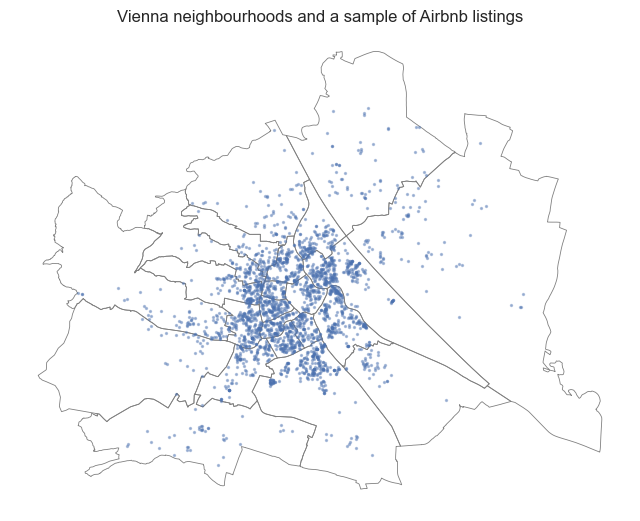

In [4]:
# ============================================================
# 3. Quick map check
# ============================================================
sample_points = spatial.sample(min(2500, len(spatial)), random_state=RANDOM_STATE)

ax = neighbourhoods.plot(facecolor="none", edgecolor="grey", linewidth=0.6, figsize=(8, 8))
sample_points.plot(ax=ax, markersize=2, alpha=0.4)
ax.set_title("Vienna neighbourhoods and a sample of Airbnb listings")
ax.set_axis_off()
plt.show()


## 4. Create the classification target

We will classify whether a listing is **highly rated** or not.

### Rule used
- keep listings with at least **5 reviews**
- keep listings with a non-missing `review_scores_rating`
- define:

\[
\text{highly\_rated} =
\begin{cases}
1 & \text{if review\_scores\_rating} \ge 4.8 \\
0 & \text{otherwise}
\end{cases}
\]

### Very important machine learning note
Because the target is built **from** `review_scores_rating`, we must **not use `review_scores_rating` as an input feature** later.  
If we included it, the model would be cheating. That is called **data leakage**.


In [5]:
# ============================================================
# 4. Create the target variable
# ============================================================
spatial["review_scores_rating"] = pd.to_numeric(
    spatial["review_scores_rating"],
    errors="coerce"
)

model_df = spatial.loc[
    (spatial["number_of_reviews"].fillna(0) >= 5)
    & (spatial["review_scores_rating"].notna())
].copy()

model_df["highly_rated"] = (model_df["review_scores_rating"] >= 4.8).astype(int)

print("Modeling sample shape:", model_df.shape)
print("\nClass counts:")
print(model_df["highly_rated"].value_counts())

print("\nClass proportions:")
print(model_df["highly_rated"].value_counts(normalize=True).round(3))


Modeling sample shape: (8886, 83)

Class counts:
highly_rated
1    4489
0    4397
Name: count, dtype: int64

Class proportions:
highly_rated
1    0.505
0    0.495
Name: proportion, dtype: float64


## 5. Light feature engineering

Some useful columns are not yet numeric:
- `host_identity_verified` is text like `t` / `f`
- `bathrooms_text` is text like `"1 bath"`
- `amenities` is stored like a text list

We convert them into simpler machine-readable columns.


In [6]:
# ============================================================
# 5. Light feature engineering
# ============================================================
def parse_tf(value):
    """Convert common true/false text values into 1/0."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    if text in {"t", "true", "yes", "1"}:
        return 1
    if text in {"f", "false", "no", "0"}:
        return 0

    return np.nan


def parse_bathrooms(text):
    """Extract a numeric bathroom count from text such as '1 bath'."""
    if pd.isna(text):
        return np.nan

    s = str(text).lower()

    if "half-bath" in s:
        return 0.5

    match = re.search(r"(\d+(?:\.\d+)?)", s)
    if match:
        return float(match.group(1))

    if "bath" in s:
        return 1.0

    return np.nan


def count_amenities(text):
    """Count how many amenities are listed."""
    if pd.isna(text):
        return np.nan

    s = str(text).strip()

    if s in {"", "[]"}:
        return 0

    try:
        items = ast.literal_eval(s)
        if isinstance(items, (list, tuple, set)):
            return len(items)
    except Exception:
        pass

    # Fallback: rough text-based count
    s = s.strip("[]")
    if not s:
        return 0

    pieces = [piece for piece in s.split('","') if piece.strip()]
    return len(pieces)


prep_df = model_df.copy()

prep_df["host_identity_verified_num"] = prep_df["host_identity_verified"].map(parse_tf)
prep_df["bathrooms_num"] = prep_df["bathrooms_text"].map(parse_bathrooms)
prep_df["amenity_count"] = prep_df["amenities"].map(count_amenities)

preview_cols = [
    "host_identity_verified",
    "host_identity_verified_num",
    "bathrooms_text",
    "bathrooms_num",
    "amenities",
    "amenity_count",
]
prep_df[preview_cols].head()


,host_identity_verified,host_identity_verified_num,bathrooms_text,bathrooms_num,amenities,amenity_count
0,t,1.0,1 bath,1.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",55
1,t,1.0,1 bath,1.0,"[""Smoke alarm"", ""Stove"", ""Coffee maker"", ""Drye...",20
2,t,1.0,1 bath,1.0,"[""Smoke alarm"", ""Coffee"", ""Pack \u2019n play/T...",58
3,t,1.0,1 bath,1.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",56
5,t,1.0,1 bath,1.0,"[""Smoke alarm"", ""Clothing storage: closet, war...",58


## 6. Choose the input features

We divide features into two groups:

### Numeric features
These already represent numbers, or we engineered them into numbers.

### Categorical features
These are labels such as room type or neighbourhood.  
The computer cannot directly use text labels, so later we will transform them.

### Why is `review_scores_rating` excluded?
Because the target `highly_rated` was created from it.  
Including it would leak the answer into the model.


In [7]:
# ============================================================
# 6. Feature lists
# ============================================================
numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "host_identity_verified_num",
    "amenity_count",
    "calculated_host_listings_count",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_joined",
    "host_response_time",
]

excluded_on_purpose = [
    "review_scores_rating",  # leakage: target was built from this variable
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nExcluded on purpose:")
print(excluded_on_purpose)


Numeric features:
['latitude', 'longitude', 'accommodates', 'bathrooms_num', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'host_identity_verified_num', 'amenity_count', 'calculated_host_listings_count']

Categorical features:
['room_type', 'property_type', 'neighbourhood_joined', 'host_response_time']

Excluded on purpose:
['review_scores_rating']


## 7. Build one classification model step by step

We now do the full workflow once with **Logistic Regression**.

This is the exact sequence students should understand clearly:

1. create `X` and `y`
2. split into training and test data
3. build the numeric preprocessing branch
4. build the categorical preprocessing branch
5. combine them with a `ColumnTransformer`
6. attach the classifier using a `Pipeline`
7. fit on training data
8. predict on test data
9. evaluate the results


In [8]:
# ============================================================
# 7. Create X and y, then split into train and test
# ============================================================
X = prep_df[numeric_features + categorical_features].copy()
y = prep_df["highly_rated"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train positive rate:", y_train.mean().round(3))
print("y_test positive rate:", y_test.mean().round(3))


X_train shape: (6664, 18)
X_test shape: (2222, 18)
y_train positive rate: 0.505
y_test positive rate: 0.505


## 8. The numeric preprocessing branch

For numeric columns we do two things:

1. **Imputation**: fill missing values with the median
2. **Scaling**: put variables onto a comparable scale

Scaling is especially useful for models such as:
- Logistic Regression
- KNN
- SVM

It is usually less important for Decision Trees, but using one common preprocessing pattern keeps the workflow consistent.


In [9]:
# ============================================================
# 8. Numeric preprocessing branch
# ============================================================
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 9. The categorical preprocessing branch

For categorical columns we do two things:

1. **Imputation**: fill missing labels with the most frequent category
2. **One-hot encoding**: convert each category into machine-readable binary columns

Example:
- `room_type = "Private room"` becomes one indicator column
- `room_type = "Entire home/apt"` becomes another indicator column


In [10]:
# ============================================================
# 9. Categorical preprocessing branch
# ============================================================
try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Fallback for older scikit-learn versions
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", categorical_encoder),
    ]
)

categorical_transformer


Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

## 10. Combine both branches into one preprocessor

`ColumnTransformer` lets us say:

- send the numeric columns to the numeric branch,
- send the categorical columns to the categorical branch,
- then combine the outputs into one model-ready matrix.


In [11]:
# ============================================================
# 10. Full preprocessor
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'accommodates',
                                  'bathrooms_num', 'bedrooms', 'beds',
                                  'minimum_nights', 'maximum_nights',
                                  'availability_365', 'number_of_reviews',
                                  'reviews_per_month',
                                  'host_identity_verified_num', 'amenity_count',
                                  'calculated_host_listings_count']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['room_type', 'property_type',
                                  'neighbourhood_joined',
                                  'host_response_time'])])

## 11. Attach the model using a pipeline

A machine learning pipeline is useful because it keeps the order correct:

1. preprocess the training data
2. train the model
3. when predicting, apply the same preprocessing to the test data automatically

This reduces mistakes and makes the code cleaner.


In [12]:
# ============================================================
# 11. Build the first full pipeline: Logistic Regression
# ============================================================
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000)),
    ]
)

logistic_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'accommodates',
                                                   'bathrooms_num', 'bedrooms',
                                                   'beds', 'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'host_identity_verified_num',
                                                   'amenity_count',
                                                   'calculated_host_listings_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['room_type', 'property_type',
                                                   'neighbourhood_joined',
                                                   'host_response_time'])])),
                ('classifier', LogisticRegression(max_iter=3000))])

## 12. Fit the model and make predictions


In [13]:
# ============================================================
# 12. Train the logistic regression pipeline
# ============================================================
logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)

print("Logistic Regression results")
print("---------------------------")
print(f"Accuracy : {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall   : {logistic_recall:.3f}")


Logistic Regression results
---------------------------
Accuracy : 0.651
Precision: 0.646
Recall   : 0.684


## 13. Confusion matrix for the first model

The confusion matrix helps students see the error types:
- true negatives,
- false positives,
- false negatives,
- true positives.


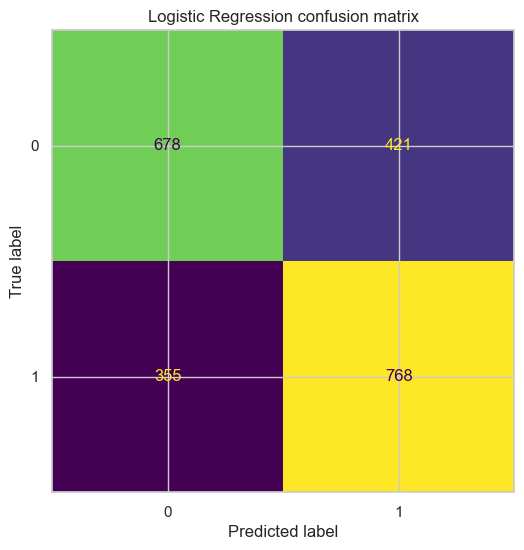

In [14]:
# ============================================================
# 13. Confusion matrix for Logistic Regression
# ============================================================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    colorbar=False,
)
plt.title("Logistic Regression confusion matrix")
plt.show()


## 14. A reusable helper function

Now that students have seen the full workflow once, we can wrap the repeated pattern into a helper function.

### What the function does
For a given model, it will:
1. build a fresh pipeline,
2. fit the pipeline,
3. predict on the test set,
4. compute the metrics,
5. return both the metrics and the fitted pipeline.

### Why this is useful
Without a helper function, we would repeat almost the same code for every classifier.

### Read the comments inside the code carefully
Each line is commented so students can understand the logic.


In [15]:
# ============================================================
# 14. Helper function for one classifier
# ============================================================
def train_and_evaluate_classifier(model_name, model_object, preprocessor, X_train, X_test, y_train, y_test):
    # Step 1: Build a brand-new pipeline for this specific model.
    # The same preprocessor is reused, but the classifier can change.
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model_object),
        ]
    )

    # Step 2: Learn from the training data.
    # During fitting, the pipeline first learns the preprocessing rules
    # on X_train and then trains the classifier on the processed data.
    pipeline.fit(X_train, y_train)

    # Step 3: Predict labels for the unseen test data.
    y_pred = pipeline.predict(X_test)

    # Step 4: Compute evaluation metrics.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Step 5: Put the metrics into a small dictionary.
    results_row = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
    }

    # Step 6: Return everything we may want to reuse later:
    # - the result row,
    # - the fitted pipeline,
    # - the test predictions.
    return results_row, pipeline, y_pred


## 15. Reuse the same logic for multiple classifiers

Now we compare three models:

- Logistic Regression
- KNN
- Decision Tree

The code structure is now shorter because the repeated logic is inside the helper function.


In [16]:
# ============================================================
# 15. Compare multiple classification models
# ============================================================
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        min_samples_leaf=10,
    ),
}

rows = []
fitted_pipelines = {}
predictions = {}

for model_name, model_object in classification_models.items():
    result_row, fitted_pipeline, y_pred = train_and_evaluate_classifier(
        model_name=model_name,
        model_object=model_object,
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    rows.append(result_row)
    fitted_pipelines[model_name] = fitted_pipeline
    predictions[model_name] = y_pred

results_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall
0,Decision Tree,0.654365,0.683938,0.587711
1,Logistic Regression,0.650765,0.645921,0.683882
2,KNN,0.633663,0.639064,0.632235


## 16. Visual comparison of model accuracy


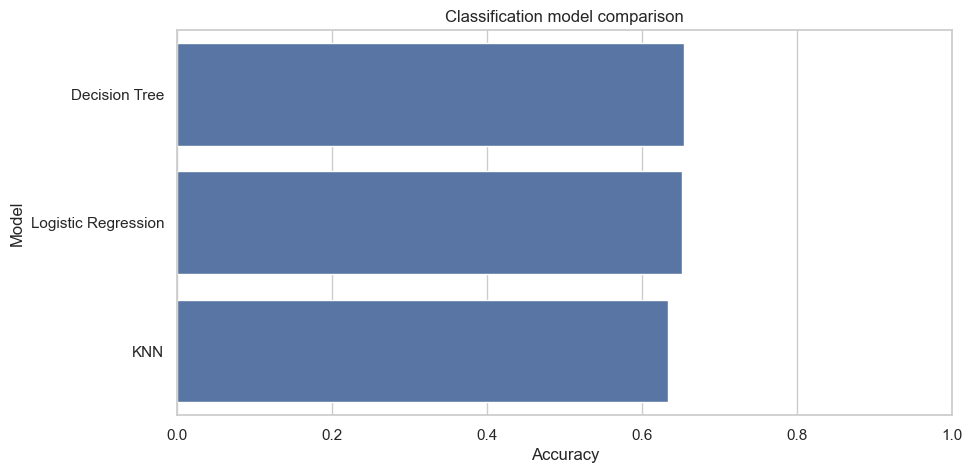

In [17]:
# ============================================================
# 16. Plot accuracy comparison
# ============================================================
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.xlim(0, 1)
plt.title("Classification model comparison")
plt.show()


## 17. Hyperparameter playground

A hyperparameter is a setting we choose **before** training.

Examples:
- KNN: number of neighbors
- Decision Tree: maximum depth

Students can rerun these cells and observe how model performance changes.


In [18]:
# ============================================================
# 17A. Hyperparameter play: KNN
# ============================================================
knn_rows = []

for k in [3, 5, 7, 9, 11]:
    result_row, _, _ = train_and_evaluate_classifier(
        model_name=f"KNN (k={k})",
        model_object=KNeighborsClassifier(n_neighbors=k),
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )
    knn_rows.append(result_row)

knn_tuning_results = pd.DataFrame(knn_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
knn_tuning_results


,Model,Accuracy,Precision,Recall
0,KNN (k=11),0.641764,0.643547,0.652716
1,KNN (k=9),0.636814,0.641831,0.636687
2,KNN (k=7),0.633663,0.639064,0.632235
3,KNN (k=5),0.620162,0.625789,0.617988
4,KNN (k=3),0.617012,0.622523,0.615316


In [19]:
# ============================================================
# 17B. Hyperparameter play: Decision Tree
# ============================================================
tree_rows = []

for depth in [3, 5, 8, 12, None]:
    result_row, _, _ = train_and_evaluate_classifier(
        model_name=f"Decision Tree (max_depth={depth})",
        model_object=DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=depth,
            min_samples_leaf=10,
        ),
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )
    tree_rows.append(result_row)

tree_tuning_results = pd.DataFrame(tree_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
tree_tuning_results


,Model,Accuracy,Precision,Recall
0,Decision Tree (max_depth=5),0.666067,0.647560,0.744435
1,Decision Tree (max_depth=3),0.662466,0.629066,0.809439
2,Decision Tree (max_depth=8),0.654365,0.683938,0.587711
3,Decision Tree (max_depth=12),0.652565,0.658824,0.648264
4,Decision Tree (max_depth=None),0.648515,0.661017,0.625111


## 18. Prepare a handoff file for the regression tutorial

The next tutorial notebook will use a cleaner table rather than repeating the full geospatial preprocessing from the start.

This file is saved as:

`vienna_airbnb_notebook2_ready.csv`


In [20]:
# ============================================================
# 18. Export a clean handoff file for Notebook 2
# ============================================================
export_columns = numeric_features + categorical_features + [
    "price",
    "review_scores_rating",
    "highly_rated",
]

notebook2_ready = prep_df[export_columns].copy()
export_path = Path("vienna_airbnb_notebook2_ready.csv")
notebook2_ready.to_csv(export_path, index=False)

print("Saved:", export_path.resolve())
print("Rows:", len(notebook2_ready))
print("Columns:", len(notebook2_ready.columns))


Saved: C:\Users\deys1\OneDrive - Aalto University\Aalto_Work_Postdoc\TUGraz_GeoAI_CourseDevelopment\AirBnbData\Austria\vienna_airbnb_notebook2_ready.csv
Rows: 8886
Columns: 21


## 19. What students should remember from this notebook

1. A machine learning workflow must keep **training** and **testing** separate.
2. Preprocessing should happen in a reproducible, organized way.
3. A pipeline is useful because it keeps preprocessing and modeling together.
4. Once the logic is clear for one model, the same pattern can be reused for many models.
5. We avoided PCA here on purpose so the main workflow stays easy to follow.
